# ARIA - LITE

ARIA Lite is a lightweight GraphRAG-based biomedical research assistant focused on breast cancer AI literature.

The project combines two retrieval paradigms:

1. Semantic Retrieval
   Dense vector embeddings are used to retrieve papers semantically related to a user query.

2. Graph-Based Retrieval
   Biomedical entities such as genes and drugs are extracted from papers and represented as relationships in a lightweight knowledge graph.

By combining these two approaches, the system aims to provide more grounded and explainable retrieval compared to traditional vector-only RAG systems.

The project is intentionally scoped for rapid iteration and learning:
- ~300-500 PubMed papers
- Abstract-only corpus
- Lightweight graph construction
- Citation-grounded responses

Core technologies:
- PubMed / Entrez API
- SciSpacy
- Sentence Transformers
- FAISS
- Python + Google Colab

End Goal:
Build a small but functional biomedical GraphRAG system capable of retrieving relevant breast cancer AI papers and generating grounded answers with PMID citations.

# 7_local_traversal.ipynb


In [1]:
# ============================================================
# SECTION 0 — Install Libraries
# ============================================================

!pip install -U spacy
!pip install -U scispacy
!pip install https://s3-us-west-2.amazonaws.com/ai2-s2-scispacy/releases/v0.5.4/en_core_sci_md-0.5.4.tar.gz -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 33.2/33.2 MB 45.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.9/3.9 MB 76.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.7/50.7 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 84.0 MB/s eta 0:00:00
  Attempting uninstall: confection
    Found existing installation: confection 0.1.5
    Uninstalling confection-0.1.5:
      Successfully uninstalled confection-0.1.5
  Attempting uninstall: blis
    Found existing installation: blis 0.7.11
    Uninstalling blis-0.7.11:
      Successfully uninstalled blis-0.7.11
  Attempting uninstall: thinc
    Found existing installation: thinc 8.2.5
    Uninstalling thinc-8.2.5:
      Successfully uninstalled thinc-8.2.5
  Attempting uninstall: weasel
    Found existing installation: weasel 0.4.3
    Uninstalling weasel-0.4.3:
      Successfully uninstalled weasel-0.4.3
  Attempting uninstall: spacy
    Found existing installation: spacy 3.7

In [2]:
# ============================================================
# SECTION 1 — IMPORTS
# ============================================================

import os
import pickle
import networkx as nx
from collections import defaultdict
import spacy
import matplotlib.pyplot as plt
from google.colab import drive

In [3]:
# ============================================================
# SECTION 2 — LOAD SciSpacy MODEL
# ============================================================

nlp = spacy.load("en_core_sci_md")

/usr/local/lib/python3.12/dist-packages/spacy/language.py:2195: FutureWarning: Possible set union at position 6328
  deserializers["tokenizer"] = lambda p: self.tokenizer.from_disk(  # type: ignore[union-attr]


In [4]:
# ============================================================
# SECTION 3 — ENTITY EXTRACTION
# ============================================================

def extract_query_entities(query):
    """
    Extract biomedical entities from query using SciSpacy.
    """
    doc = nlp(query)
    entities = set()

    for ent in doc.ents:
        entities.add(ent.text.lower())

    return list(entities)

In [5]:
# ============================================================
# SECTION 4 — SEED NODE MAPPING
# ============================================================

def get_seed_nodes(query_entities, entity_to_nodes):
    """
    Map extracted entities → graph nodes.
    """
    seeds = []

    for ent in query_entities:
        if ent in entity_to_nodes:
            seeds.extend(entity_to_nodes[ent])

    return list(set(seeds))

In [6]:
# ============================================================
# SECTION 5 — LOCAL GRAPH TRAVERSAL ENGINE
# ============================================================

from collections import defaultdict

def local_traversal(
    graph,
    seed_nodes,
    max_hops=2,
    max_section_expansion=25
):

    """
    Local Graph Traversal

    Input:
        graph
        seed_nodes = matched query entities

    Output:
        retrieved_sections
        traversal_records
    """

    retrieved_sections = set()

    traversal_records = []

    # --------------------------------------------------------
    # HOP 1
    # ENTITY <-> SECTION
    # --------------------------------------------------------

    first_sections = set()

    for entity in seed_nodes:

        if entity not in graph:
            continue

        for nbr in graph.neighbors(entity):

            nbr_type = graph.nodes[nbr].get("type")

            # ----------------------------------------
            # ENTITY -> SECTION
            # ----------------------------------------
            if nbr_type == "section":

                edge_type = graph.edges[entity, nbr].get(
                    "type",
                    "MENTIONS"
                )

                first_sections.add(nbr)
                retrieved_sections.add(nbr)

                traversal_records.append({
                    "source": entity,
                    "edge": edge_type,
                    "target": nbr,
                    "hop": 1,
                    "score": 3
                })

    # --------------------------------------------------------
    # HOP 2
    # SECTION -> ENTITY -> SECTION
    # --------------------------------------------------------

    if max_hops >= 2:

        second_sections = set()

        for section in first_sections:

            for nbr in graph.neighbors(section):

                nbr_type = graph.nodes[nbr].get("type")

                # ------------------------------------
                # SECTION -> ENTITY
                # ------------------------------------
                if nbr_type == "entity":

                    edge_type = graph.edges[section, nbr].get(
                        "type",
                        "UNKNOWN"
                    )

                    traversal_records.append({
                        "source": section,
                        "edge": edge_type,
                        "target": nbr,
                        "hop": 2,
                        "score": 2
                    })

                    # ------------------------------------------------
                    # LIMIT SECTION EXPANSION
                    # Prevent graph explosion from supernodes
                    # ------------------------------------------------

                    connected_sections = []

                    for sec2 in graph.neighbors(nbr):

                        if graph.nodes[sec2].get("type") == "section":
                            connected_sections.append(sec2)

                    # limit expansion
                    connected_sections = connected_sections[
                        :max_section_expansion
                    ]

                    # ------------------------------------------------
                    # ENTITY -> SECTION
                    # ------------------------------------------------

                    for sec2 in connected_sections:

                        edge2 = graph.edges[nbr, sec2].get(
                            "type",
                            "MENTIONS"
                        )

                        second_sections.add(sec2)
                        retrieved_sections.add(sec2)

                        traversal_records.append({
                            "source": nbr,
                            "edge": edge2,
                            "target": sec2,
                            "hop": 2,
                            "score": 2
                        })

    return list(retrieved_sections), traversal_records

In [7]:
# ============================================================
# SECTION 6 — SECTION SCORING
# ============================================================

from collections import defaultdict

def score_sections(
    query_entities,
    retrieved_sections,
    traversal_records,
    graph
):

    """
    Score retrieved sections based on:
    - edge type
    - hop distance
    - entity overlap
    - deduplicated traversal paths
    """

    query_entities = set([
        e.lower() for e in query_entities
    ])

    section_scores = defaultdict(float)

    section_paths = defaultdict(list)

    # --------------------------------------------------------
    # DEDUPLICATE PATHS ARE RECORDED
    # --------------------------------------------------------

    seen_paths = set()

    # --------------------------------------------------------
    # SCORE VIA TRAVERSAL RECORDS
    # --------------------------------------------------------

    for record in traversal_records:

        source = record["source"]
        edge = record["edge"]
        target = record["target"]
        hop = record["hop"]

        # ----------------------------------------------------
        # only score section targets
        # ----------------------------------------------------

        if target not in retrieved_sections:
            continue

        # ----------------------------------------------------
        # UNIQUE PATH KEY
        # ----------------------------------------------------

        path_key = (
            source,
            edge,
            target,
            hop
        )

        # skip duplicate paths
        if path_key in seen_paths:
            continue

        seen_paths.add(path_key)

        score = 0

        # ----------------------------------------------------
        # EDGE WEIGHTS
        # ----------------------------------------------------

        if edge == "MENTIONS":
            score += 3

        elif edge == "SIMILAR_SECTION":
            score += 2

        elif edge == "CO_OCCURS":
            score += 1

        # ----------------------------------------------------
        # STRONGER HOP PENALTIES
        # ----------------------------------------------------

        if hop == 1:

            # direct evidence
            score += 5

        elif hop == 2:

            # weaker contextual evidence
            score += 1

        elif hop >= 3:

            # penalize distant traversal
            score -= 2

        # ----------------------------------------------------
        # ENTITY OVERLAP BONUS
        # ----------------------------------------------------

        section_text = graph.nodes[target].get(
            "text",
            ""
        ).lower()

        overlap = 0

        for ent in query_entities:

            if ent in section_text:
                overlap += 1

        score += overlap * 2

        # ----------------------------------------------------
        # STORE SCORE
        # ----------------------------------------------------

        section_scores[target] += score

        section_paths[target].append(record)

    # --------------------------------------------------------
    # BUILD RANKED OUTPUT
    # --------------------------------------------------------

    ranked_sections = []

    for section, score in section_scores.items():

        ranked_sections.append({

            "section_id": section,

            "score": round(score, 2),

            "text": graph.nodes[section].get(
                "text",
                ""
            ),

            "paper_id": graph.nodes[section].get(
                "paper_id",
                ""
            ),

            "paths": section_paths[section]
        })

    ranked_sections = sorted(
        ranked_sections,
        key=lambda x: x["score"],
        reverse=True
    )

    return ranked_sections

In [8]:
# ============================================================
# SECTION 7 — EXPLAINABILITY VISUALIZATION
# ============================================================

import networkx as nx
import matplotlib.pyplot as plt

def visualize_traversal(graph, ranked_sections, top_k=3):

    """
    Visualize retrieval paths.
    """

    viz_graph = nx.Graph()

    # --------------------------------------------------------
    # ADD PATHS
    # --------------------------------------------------------

    for item in ranked_sections[:top_k]:

        for path in item["paths"]:

            src = path["source"]
            tgt = path["target"]
            edge = path["edge"]

            viz_graph.add_node(src)
            viz_graph.add_node(tgt)

            viz_graph.add_edge(src, tgt, label=edge)

    # --------------------------------------------------------
    # DRAW
    # --------------------------------------------------------

    plt.figure(figsize=(14, 10))

    pos = nx.spring_layout(viz_graph, seed=42)

    nx.draw(
        viz_graph,
        pos,
        with_labels=True,
        node_size=1800,
        font_size=8
    )

    edge_labels = nx.get_edge_attributes(
        viz_graph,
        "label"
    )

    nx.draw_networkx_edge_labels(
        viz_graph,
        pos,
        edge_labels=edge_labels,
        font_size=7
    )

    plt.title("ARIA Local Traversal Explainability")

    plt.show()

In [9]:
# ============================================================
# SECTION 8 — COMPLETE LOCAL RETRIEVAL PIPELINE
# ============================================================

def run_local_query(graph, query):

    print("\n==============================")
    print("QUERY")
    print("==============================")
    print(query)

    # --------------------------------------------------------
    # ENTITY EXTRACTION
    # --------------------------------------------------------

    query_entities = extract_query_entities(query)

    print("\nExtracted Entities:")
    print(query_entities)

    # --------------------------------------------------------
    # ENTITY MATCHING
    # --------------------------------------------------------

    matched_entities = []

    for ent in query_entities:

        if ent in graph:
            matched_entities.append(ent)

    STOPWORDS = [
    "breast cancer",
    "cancer",
    "tumor",
    "disease",
    "patient"]

    matched_entities = [e for e in matched_entities if e.lower() not in STOPWORDS]

    print("\nMatched Entities:")
    print(matched_entities)

    # --------------------------------------------------------
    # TRAVERSAL
    # --------------------------------------------------------

    retrieved_sections, traversal_records = local_traversal(
        graph,
        matched_entities
    )

    print("\nRetrieved Sections:")
    print(len(retrieved_sections))

    # --------------------------------------------------------
    # SCORING
    # --------------------------------------------------------

    ranked_sections = score_sections(
        matched_entities,
        retrieved_sections,
        traversal_records,
        graph
    )

    # --------------------------------------------------------
    # DISPLAY TOP RESULTS
    # --------------------------------------------------------

    print("\n==============================")
    print("TOP RETRIEVED SECTIONS")
    print("==============================")

    for idx, item in enumerate(ranked_sections[:5]):

        print(f"\nRANK {idx+1}")
        print("SECTION:", item["section_id"])
        print("SCORE:", item["score"])

        print("\nTEXT:")
        print(item["text"][:700])

    # --------------------------------------------------------
    # VISUALIZATION
    # --------------------------------------------------------

    visualize_traversal(graph, ranked_sections)

    return ranked_sections

Mounted at /content/drive
Graph loaded

QUERY
How does trastuzumab target HER2 in breast cancer?

Extracted Entities:
['trastuzumab', 'breast cancer', 'her2']

Matched Entities:
['trastuzumab', 'her2']

Retrieved Sections:
656

TOP RETRIEVED SECTIONS

RANK 1
SECTION: 42009845_UNLABELLED
SCORE: 144.0

TEXT:
p95HER2 is commonly expressed in human epidermal growth factor receptor 2 (HER2)-positive breast cancer (BC) and is generated primarily from shedding of the extracellular domain of HER2. p95HER2 is oncogenic, driving aggressive tumor growth, and conferring drug resistance. Targeting p95HER2 is challenging. Clinically approved HER2 inhibitors either cannot bind to p95HER2 or show limited inhibitory effects. We used cell lines and orthotopic tumor models (cell line xenografts and patient derived xenografts) to investigate the effects of HER2 inhibitors on p95HER2 and other key signaling proteins in HER2-positive BC, and to compare the therapeutic activities of different HER2 inhibitors

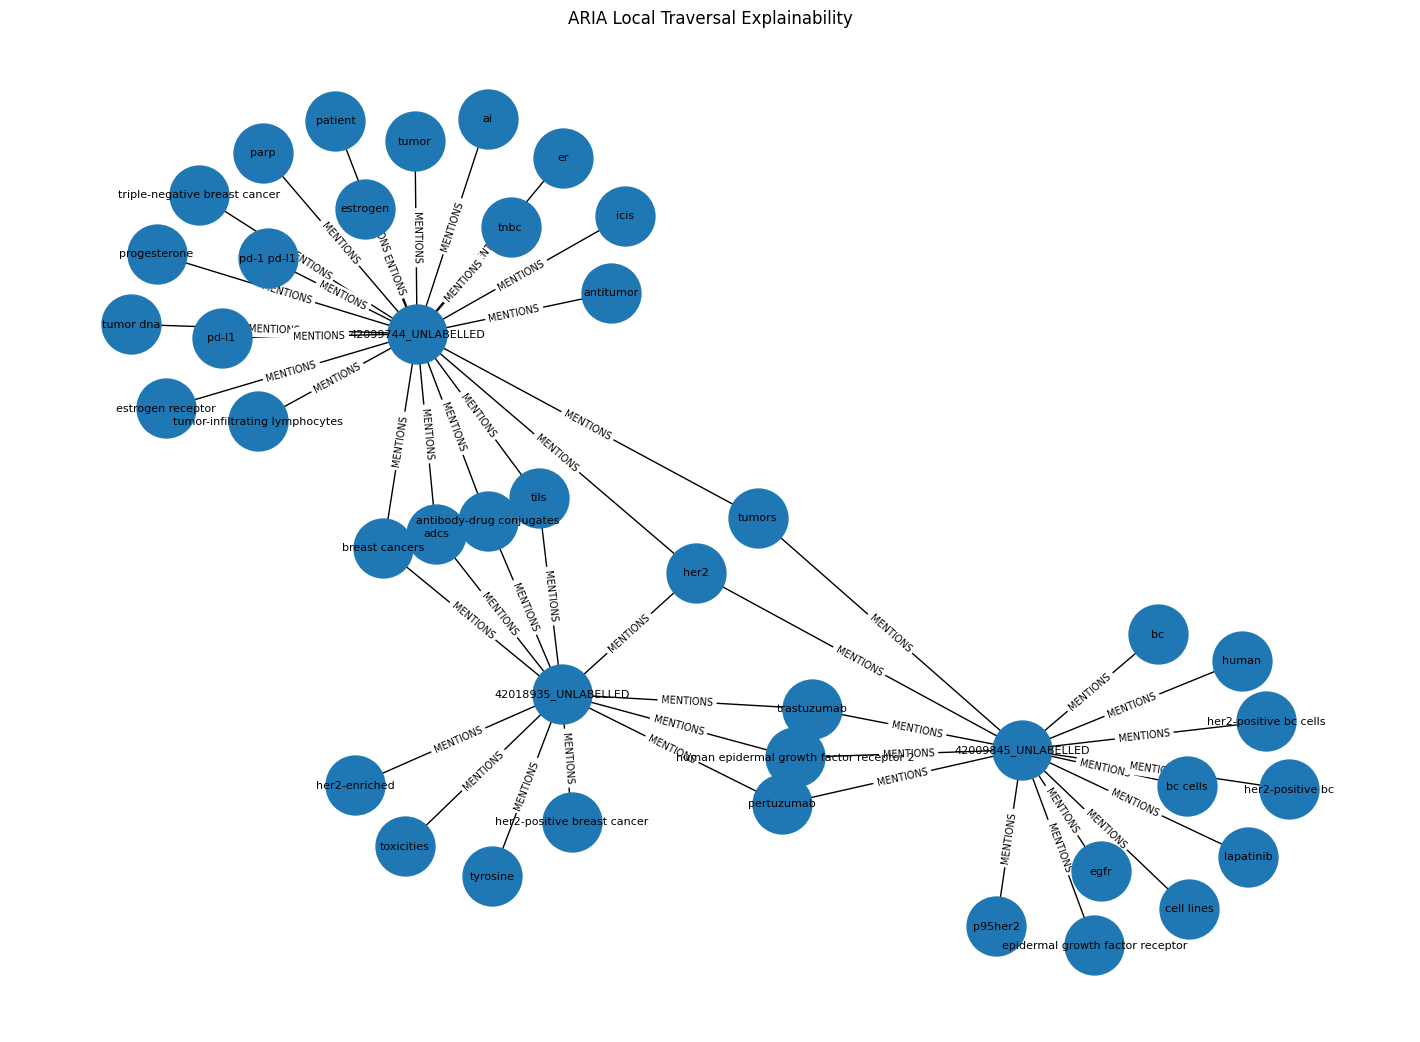

In [10]:
# ============================================================
# SECTION 9 — TEST QUERY
# ============================================================

drive.mount('/content/drive')

PROJECT_ROOT = "/content/drive/MyDrive/Colab_Notebooks/LLMs/ARIA_Lite_v2"

GRAPH_PATH = os.path.join(
    PROJECT_ROOT,
    "data",
    "processed",
    "aria_lite_graph_v2_1_communities_v1.pkl"
)

with open(GRAPH_PATH, "rb") as f:
    G = pickle.load(f)

print("Graph loaded")

query = "How does trastuzumab target HER2 in breast cancer?"

results = run_local_query(G, query)